In [142]:
%load_ext autoreload
%autoreload 2
%env CUDA_VISIBLE_DEVICES=1

import numpy as np
import sys
import os
import matplotlib.pyplot as plt
import vis_utils

from utils.utils import get_path
from utils.io_utils import load_multiple_res
from utils.toydata_utils import get_toy_data
from utils.fig_utils import dataset_to_print, plot_dgm_loops, dist_to_print
from utils.pd_utils import sort_cycle

from vis_utils.loaders import load_dataset
from vis_utils.plot import plot_scatter
from vis_utils.utils import load_dict, save_dict
from vis_utils.tsne_wrapper import TSNEwrapper
from openTSNE.affinity import Affinities

import umap
from ripser import Rips
from ripser.ripser import get_greedy_perm

from mpl_toolkits.axes_grid1 import make_axes_locatable

from matplotlib import collections  as mc
from matplotlib.colors import Normalize
import matplotlib.cm

from openTSNE.nearest_neighbors import PrecomputedNeighbors
from openTSNE.affinity import PerplexityBasedNN

from vis_utils.utils import kNN_graph, kNN_dists
from scipy.spatial.distance import pdist, squareform
import glasbey
import scipy.sparse
import networkx as nx

from sklearn.decomposition import PCA

from persim import plot_diagrams
from utils.pd_utils import get_life_times
import pandas as pd

from vis_utils.rnaseqTools import geneSelection, sparseload
import pickle
import torch
import urllib.request
import requests
 
from scipy.linalg import orthogonal_procrustes
from scipy.spatial import procrustes

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
env: CUDA_VISIBLE_DEVICES=1


<h4 style="background-color: yellow; padding: 5px;">

here i do procrustes alignation, which is to rotate the embedding of both cell groups(orange & purple) in both tasic and yao's smart seq dataset, so that the loops passing similar cell clusters would roughly appear at a similar position as yao's 10x male dataset. 

In "procrutes_10x_female.ipynb" I also rotate yao's 10x female dataset. 

At the end of this file, there is the embedding of all 4 dateset * 2 cell groups for visulisation.


</h4>

In [ ]:
root_path = get_path("data")
fig_path = get_path("figures")
# seeds = [0, 1, 2]
seeds = [0]
k = 15

style_file = "utils.style"
plt.style.use(style_file)

distances = {
    "euclidean": [{}],
}

# ------------------ smart seq ----------------------------------

# load data

note that the last element is absent, idx = 109, color is black(if nothing goes wrong...)

In [837]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
k = 15
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_10x_male = tsne_data["embds"][-1]
# embd_10x_male = (embd_10x_male- np.mean(embd_10x_male, axis=0))/np.std(embd_10x_male) 

In [838]:
file_name = os.path.join(root_path,
                         "yao_smart",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_smart = tsne_data["embds"][-1]
# embd_smart = (embd_smart - np.mean(embd_smart, axis=0))/np.std(embd_smart)

In [149]:

_,_,_,_,d_10x_male = load_dataset(root_path, "yao_10x_male", k=15, seed=0)
_,_,_,_, d_smart = load_dataset(root_path, "yao_smart", k=15, seed=0)


# making mask for figure

In [155]:
idx_orange_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_10x_fig = [idx in idx_orange_10x_fig for idx in d_10x_male['clusters']]

In [156]:
idx_purple_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_10x_fig = [idx in idx_purple_10x_fig for idx in d_10x_male['clusters']]


In [157]:
idx_orange_smart_fig = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_smart_fig = [idx in idx_orange_smart_fig for idx in d_smart['clusters']]

In [158]:
idx_purple_smart_fig = [i for i, cluster in enumerate(d_smart["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_smart_fig = [idx in idx_purple_smart_fig for idx in d_smart['clusters']]

In [ ]:
sum(mask_purple_smart_fig)

11682

In [ ]:
sum(mask_orange_smart_fig)

9902

# procrustes

In [839]:
clusters_mean_smart = []
clusters_size_smart_purple = []
for cluster in idx_purple_10x_fig:
    cluster_idx = np.where(d_smart['clusters'] == cluster)[0]
    cluster_pos = embd_smart[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_smart.append(cluster_mean)
    clusters_size_smart_purple.append(len(cluster_idx))
clusters_mean_smart_purple = np.vstack(clusters_mean_smart)
weight_smart_purple = np.vstack(clusters_size_smart_purple) / np.sum(clusters_size_smart_purple)

In [ ]:
sorted_smart_purple = [index for index, value in sorted(enumerate(weight_smart_purple), key=lambda x: x[1], reverse=True)]
cumsum_smart_purple = np.cumsum(weight_smart_purple[sorted_smart_purple])
num_smart_purple = len(cumsum_smart_purple[cumsum_smart_purple<0.6])
partial_smart_purple = sorted_smart_purple[:num_smart_purple]


In [ ]:
sum(clusters_size_smart_purple)

11682

In [ ]:
clusters_mean_smart = []
clusters_size_smart_orange = []
for cluster in idx_orange_10x_fig:
    cluster_idx = np.where(d_smart['clusters'] == cluster)[0]
    cluster_pos = embd_smart[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_smart.append(cluster_mean)
    clusters_size_smart_orange.append(len(cluster_idx))
clusters_mean_smart_orange = np.vstack(clusters_mean_smart)
weight_smart_orange = np.vstack(clusters_size_smart_orange) / np.sum(clusters_size_smart_orange)


In [ ]:
sorted_smart_orange = [index for index, value in sorted(enumerate(weight_smart_orange), key=lambda x: x[1], reverse=True)]
cumsum_smart_orange = np.cumsum(weight_smart_orange[sorted_smart_orange])
num_smart_orange = len(cumsum_smart_orange[cumsum_smart_orange<0.6])
partial_smart_orange = sorted_smart_orange[:num_smart_orange]

In [ ]:
sum(clusters_size_smart_orange)

9902

In [840]:
clusters_mean_10x = []
clusters_size_10x = []
for cluster in idx_purple_10x_fig + idx_orange_10x_fig:
    cluster_idx = np.where(d_10x_male['clusters'] == cluster)[0]
    cluster_pos = embd_10x_male[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x.append(cluster_mean)
    clusters_size_10x.append(len(cluster_idx))
clusters_mean_10x = np.vstack(clusters_mean_10x)
weight_10x = np.vstack(clusters_size_10x) / np.sum(clusters_size_10x)

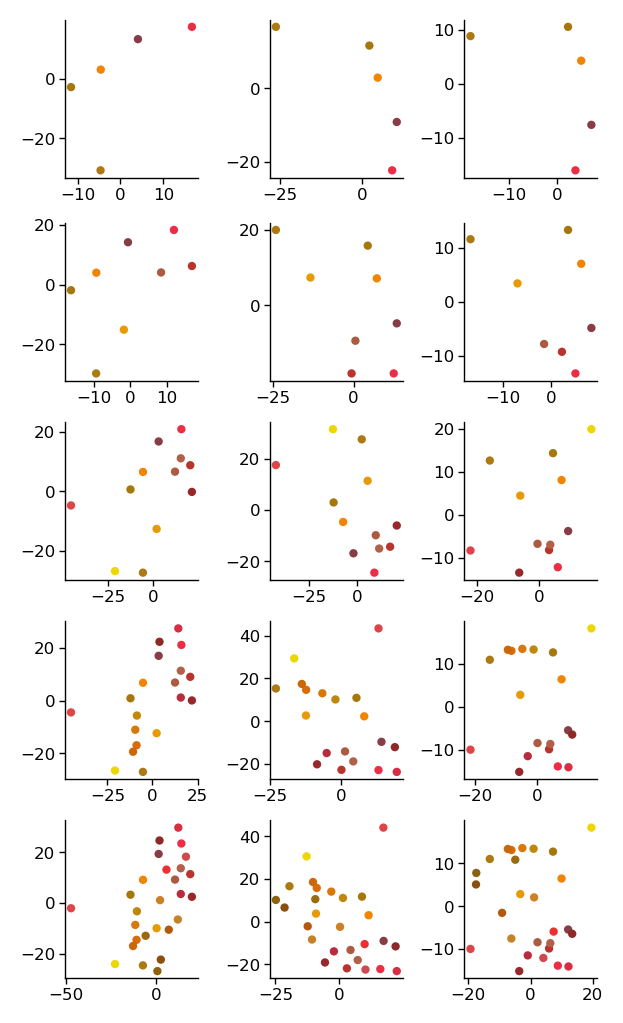

In [ ]:
#test the ratio.....best is orange 0.6. purple i think does not matter. so i just use 0.6 for both colors
fig, ax = plt.subplots(5,3, figsize = (3, 5))
ratio = [0.4,0.5,0.6,0.7,0.8]

for i, r in enumerate(ratio):
    num_smart_orange = len(cumsum_smart_orange[cumsum_smart_orange<r])
    partial_smart_orange = sorted_smart_orange[:num_smart_orange]
    
    colors = d_smart['clusterColors'][idx_orange_smart_fig][partial_smart_orange]
    ss = np.array(clusters_size_smart_orange)[partial_smart_orange]
    a = clusters_mean_smart_orange[partial_smart_orange]
    a = a - a.mean(axis=0)
    b = clusters_mean_10x[len(idx_purple_10x_fig):,:][partial_smart_orange]
    b = b - b.mean(axis=0)
    R_orange_test, sca = orthogonal_procrustes(a, b)
    c = (a@R_orange_test)

    ax[i,0].scatter(a[:,0], a[:,1], color = colors)
    ax[i,1].scatter(c[:,0], c[:,1], color = colors)
    ax[i,2].scatter(b[:,0], b[:,1], color = colors)


In [ ]:

embd_smart_after = embd_smart.copy()

a = clusters_mean_smart_orange[partial_smart_orange]
a = a - a.mean(axis=0)
b = clusters_mean_10x[len(idx_purple_10x_fig):,:][partial_smart_orange]
b = b - b.mean(axis=0)
R_orange_test, sca = orthogonal_procrustes(a, b)
c = (a@R_orange_test)
embd_smart_after[mask_orange_smart_fig] = np.dot(embd_smart_after[mask_orange_smart_fig], R_orange_test)


d = clusters_mean_smart_purple[partial_smart_purple]
d = d - d.mean(axis=0)
e = clusters_mean_10x[:len(idx_purple_10x_fig),:][partial_smart_purple]
e = e - e.mean(axis=0)
R_purple_test, sca = orthogonal_procrustes(d, e)
f = (d@R_purple_test)
embd_smart_after[mask_purple_smart_fig] = np.dot(embd_smart_after[mask_purple_smart_fig], R_purple_test)


#optional plotting...
# fig, ax = plt.subplots(2,3, figsize = (6, 4))
# colors = d_smart['clusterColors'][idx_orange_smart_fig][partial_smart_orange]
# ss_orange = np.array(clusters_size_smart_orange)[partial_smart_orange]

# ax[0,0].scatter(a[:,0], a[:,1], color = colors, s = ss_orange)# )
# ax[0,1].scatter(c[:,0], c[:,1], color = colors,s = ss_orange)# s = clusters_size_smart[len(idx_purple_10x_fig):])
# ax[0,2].scatter(b[:,0], b[:,1], color = colors,s = ss_orange)# s = clusters_size_10x[len(idx_purple_10x_fig):])


# colors = d_smart['clusterColors'][idx_purple_smart_fig][partial_smart_purple]
# ss_purple = np.array(clusters_size_smart_purple)[partial_smart_purple]
# ax[1,0].scatter(d[:,0], d[:,1], color = colors,s = ss_purple)
# ax[1,1].scatter(f[:,0], f[:,1], color = colors,s = ss_purple)
# ax[1,2].scatter(e[:,0], e[:,1], color = colors,s = ss_purple)


In [ ]:
np.save(os.path.join(root_path, "embd_after_procrustes", "embd_smart_orange.npy"), embd_smart_after[mask_orange_smart_fig])
np.save(os.path.join(root_path, "embd_after_procrustes", "embd_smart_purple.npy"), embd_smart_after[mask_purple_smart_fig])

# plot!

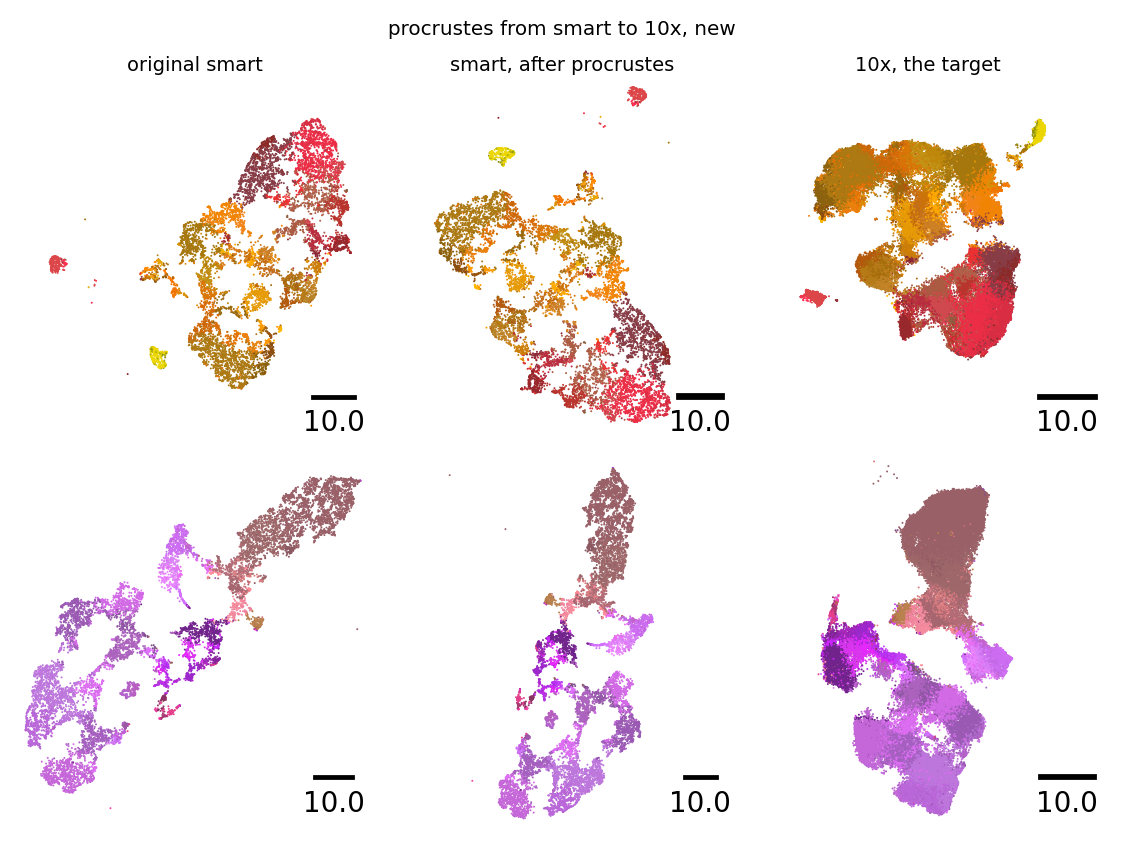

In [875]:
fig, ax = plt.subplots(2,3)
plot_scatter(ax[0,0], embd_smart[mask_orange_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_orange_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[0,1], embd_smart_after[mask_orange_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_orange_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[0,2], embd_10x_male[mask_orange_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_orange_10x_fig], s=2.0, alpha=1)

plot_scatter(ax[1,0], embd_smart[mask_purple_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_purple_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[1,1], embd_smart_after[mask_purple_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_purple_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[1,2], embd_10x_male[mask_purple_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_purple_10x_fig], s=2.0, alpha=1)
# ax[0,0].axis("on")
# ax[0,1].axis("on")
# ax[0,2].axis("on")
# ax[1,0].axis("on")
# ax[1,1].axis("on")
# ax[1,2].axis("on")


fig.suptitle("procrustes from smart to 10x, new")
ax[0,0].set_xlim(-90, -15)
ax[0,0].set_ylim(-40, 25)
ax[0,0].set_title("original smart")
ax[0,1].set_xlim(-20, 40)
ax[0,1].set_ylim(5, 85)
ax[0,1].set_title("smart, after procrustes")
ax[0,2].set_xlim(-70, -15)
ax[0,2].set_ylim(20, 70)
ax[0,2].set_title("10x, the target")

ax[1,0].set_xlim(-80, 0)
ax[1,0].set_ylim(-10, 80)
ax[1,1].set_xlim(20, 80)
ax[1,1].set_ylim(-70, 40)
ax[1,2].set_xlim(-85, -45)
ax[1,2].set_ylim(-30, 35)
fig.savefig(os.path.join(get_path("figures"), f"procrustes_smart.png"), dpi=300)

# ------------------ tasic ----------------------------------

# load data, and create another system of cell type labeling in tasic

note that the last element is absent, idx = 109, color is black(if nothing goes wrong...)

In [207]:
tasic_to_yao = load_dict(os.path.join(get_path("data") ,"yao", "tasic_to_yao.pkl"))

In [208]:
n_epochs = 500
n_early_epochs = 250
perplexity = None    
rescale_tsne = True
seed = 0
k = 15
file_name = os.path.join(root_path,
                         "yao_10x_male",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_10x_male = tsne_data["embds"][-1]

In [209]:
file_name = os.path.join(root_path,
                         "tasic",
                         f"tsne_bin_k_{k}_n_epochs_{n_epochs}_n_early_epochs_{n_early_epochs}_seed_{seed}_init_pca_rescale_{rescale_tsne}.pkl")
tsne_data = load_dict(file_name)
embd_tasic = tsne_data["embds"][-1]

In [210]:

_,_,_,_,d_10x_male = load_dataset(root_path, "yao_10x_male", k=15, seed=0)


In [661]:
_,_,_,_, d_tasic = load_dataset(root_path, "tasic", k=15, seed=0)
d_tasic['clusters_old'] = d_tasic.pop('clusters')
d_tasic['clusterColors_old'] = d_tasic.pop('clusterColors')
d_tasic['clusterNames_old'] = d_tasic.pop('clusterNames')
d_tasic['clusterNames_new'] = list(set([tasic_to_yao[i] for i in d_tasic['clusterNames_old'] if i in tasic_to_yao.keys()]))
clu_idx = np.array([np.where(d_10x_male["clusterNames"]==i)[0][0] for i in d_tasic['clusterNames_new']])
d_tasic['clusterColors_new']  = d_10x_male["clusterColors"][clu_idx]


d_tasic['clusterNames_new'] = d_tasic['clusterNames_new'] + ["absent"]
d_tasic['clusterColors_new'] = np.append(d_10x_male["clusterColors"][clu_idx], np.array(["#000000"])) #i think this is black otherwise well see.....
# #i do the color just in case.....actually dont know if its useful....but what.....
clu_129 = [i for i in d_tasic['clusterNames_old'] if i in tasic_to_yao.keys()]
d_tasic_clu = []
for i in d_tasic['clusters_old']:
    if d_tasic['clusterNames_old'][i] in clu_129:
        d_tasic_clu+= [tasic_to_yao[d_tasic['clusterNames_old'][i]]]
    else:
        d_tasic_clu+= ["absent"]
d_tasic['clusters_new'] = np.array([d_tasic['clusterNames_new'].index(i) for i in d_tasic_clu])

In [212]:
d_tasic.keys()

dict_keys(['counts', 'genes', 'areas', 'clusters_old', 'clusterColors_old', 'clusterNames_old', 'clusterNames_new', 'clusterColors_new', 'clusters_new'])

In [213]:
d_10x_male.keys()

dict_keys(['counts', 'genes', 'cells', 'clusters', 'clusterColors', 'clusterNames'])

# find orange/purple cell groups

In [214]:
cluster_orange = [cluster for i, cluster in enumerate(d_tasic["clusterNames_new"]) 
                  if "_Sst" in cluster or "_Pvalb" in cluster]
cluster_purple = [cluster for i, cluster in enumerate(d_tasic["clusterNames_new"]) 
                  if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]

In [216]:
idx_orange_10x = [list(d_10x_male["clusterNames"]).index(i) for i in cluster_orange]
idx_purple_10x = [list(d_10x_male["clusterNames"]).index(i) for i in cluster_purple]


In [217]:
#is there really need to have mask? or for now?
# mask_orange_10x = [idx in idx_orange_10x for idx in d_10x_male['clusters']]
# mask_purple_10x = [idx in idx_purple_10x for idx in d_10x_male['clusters']]


# making mask for figure

In [218]:
idx_orange_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_10x_fig = [idx in idx_orange_10x_fig for idx in d_10x_male['clusters']]

In [219]:
idx_purple_10x_fig = [i for i, cluster in enumerate(d_10x_male["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_10x_fig = [idx in idx_purple_10x_fig for idx in d_10x_male['clusters']]


In [220]:
idx_orange_tasic_fig = [i for i, cluster in enumerate(d_tasic["clusterNames_new"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_tasic_fig = [idx in idx_orange_tasic_fig for idx in d_tasic['clusters_new']]

In [221]:
idx_purple_tasic_fig = [i for i, cluster in enumerate(d_tasic["clusterNames_new"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_tasic_fig = [idx in idx_purple_tasic_fig for idx in d_tasic['clusters_new']]

# procrustes

In [ ]:
r = 0.7

clusters_mean_tasic_orange = []
clusters_size_tasic_orange = []
for cluster in idx_orange_tasic_fig:
    cluster_idx = np.where(d_tasic["clusters_new"] == cluster)[0]
    cluster_pos = embd_tasic[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_tasic_orange.append(cluster_mean)
    clusters_size_tasic_orange.append(len(cluster_idx))
clusters_mean_tasic_orange = np.vstack(clusters_mean_tasic_orange)
weight_tasic_orange = np.vstack(clusters_size_tasic_orange) / np.sum(clusters_size_tasic_orange)

sorted_tasic_orange = [index for index, value in sorted(enumerate(weight_tasic_orange), key=lambda x: x[1], reverse=True)]
cumsum_tasic_orange = np.cumsum(weight_tasic_orange[sorted_tasic_orange])
num_tasic_orange = len(cumsum_tasic_orange[cumsum_tasic_orange<r])
partial_tasic_orange = sorted_tasic_orange[:num_tasic_orange]


clusters_mean_tasic_purple = []
clusters_size_tasic_purple = []
for cluster in idx_purple_tasic_fig:
    cluster_idx = np.where(d_tasic["clusters_new"] == cluster)[0]
    cluster_pos = embd_tasic[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_tasic_purple.append(cluster_mean)
    clusters_size_tasic_purple.append(len(cluster_idx))
clusters_mean_tasic_purple = np.vstack(clusters_mean_tasic_purple)
weight_tasic_purple = np.vstack(clusters_size_tasic_purple) / np.sum(clusters_size_tasic_purple)


sorted_tasic_purple = [index for index, value in sorted(enumerate(weight_tasic_purple), key=lambda x: x[1], reverse=True)]
cumsum_tasic_purple = np.cumsum(weight_tasic_purple[sorted_tasic_purple])
num_tasic_purple = len(cumsum_tasic_purple[cumsum_tasic_purple<r])
partial_tasic_purple = sorted_tasic_purple[:num_tasic_purple]



In [ ]:
clusters_mean_10x_orange = []
# clusters_size_10x_orange = []
for cluster in idx_orange_10x:
    cluster_idx = np.where(d_10x_male['clusters'] == cluster)[0]
    cluster_pos = embd_10x_male[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x_orange.append(cluster_mean)
    # clusters_size_10x_orange.append(len(cluster_idx))
clusters_mean_10x_orange = np.vstack(clusters_mean_10x_orange)
# weight_10x_orange = np.vstack(clusters_size_10x_orange) / np.sum(clusters_size_10x_orange)

clusters_mean_10x_purple = []
# clusters_size_10x_purple = []
for cluster in idx_purple_10x:
    cluster_idx = np.where(d_10x_male['clusters'] == cluster)[0]
    cluster_pos = embd_10x_male[cluster_idx]
    cluster_mean = np.mean(cluster_pos, axis=0)
    clusters_mean_10x_purple.append(cluster_mean)
    # clusters_size_10x_purple.append(len(cluster_idx))
clusters_mean_10x_purple = np.vstack(clusters_mean_10x_purple)
# weight_10x_purple = np.vstack(clusters_size_10x_purple) / np.sum(clusters_size_10x_purple)


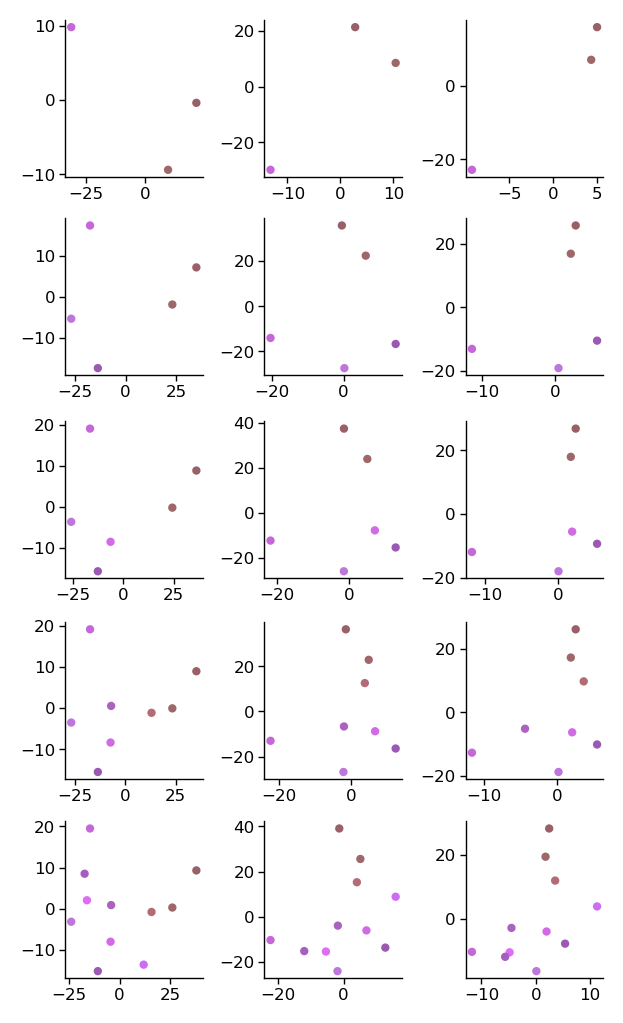

In [707]:
#test the ratio.....best is orange 0.8. purple i think does not matter. so i just use 0.8 for both.
fig, ax = plt.subplots(5,3, figsize = (3, 5))
ratio = [0.4,0.5,0.6,0.7,0.8]
# for i, r in enumerate(ratio):
#     num_tasic_orange = len(cumsum_tasic_orange[cumsum_tasic_orange<r])
#     partial_tasic_orange = sorted_tasic_orange[:num_tasic_orange]
    
#     colors = d_tasic['clusterColors_new'][idx_orange_tasic_fig][partial_tasic_orange]
#     ss = np.array(clusters_size_tasic_orange)[partial_tasic_orange]
#     a = clusters_mean_tasic_orange[partial_tasic_orange]
#     a = a - a.mean(axis=0)
#     b = clusters_mean_10x_orange[partial_tasic_orange]
#     b = b - b.mean(axis=0)
#     R_orange_test, sca = orthogonal_procrustes(a, b)
#     c = (a@R_orange_test)

#     ax[i,0].scatter(a[:,0], a[:,1], color = colors)
#     ax[i,1].scatter(c[:,0], c[:,1], color = colors)
#     ax[i,2].scatter(b[:,0], b[:,1], color = colors)
for i, r in enumerate(ratio):
    num_tasic_purple = len(cumsum_tasic_purple[cumsum_tasic_purple<r])
    partial_tasic_purple = sorted_tasic_purple[:num_tasic_purple]
    
    colors = d_tasic['clusterColors_new'][idx_purple_tasic_fig][partial_tasic_purple]
    ss = np.array(clusters_size_tasic_purple)[partial_tasic_purple]
    a = clusters_mean_tasic_purple[partial_tasic_purple]
    a = a - a.mean(axis=0)
    b = clusters_mean_10x_purple[partial_tasic_purple]
    b = b - b.mean(axis=0)
    R_purple_test, sca = orthogonal_procrustes(a, b)
    c = (a@R_purple_test)

    ax[i,0].scatter(a[:,0], a[:,1], color = colors)
    ax[i,1].scatter(c[:,0], c[:,1], color = colors)
    ax[i,2].scatter(b[:,0], b[:,1], color = colors)

In [765]:
embd_tasic_after = embd_tasic.copy()


a = clusters_mean_tasic_orange[partial_tasic_orange]
a = a - a.mean(axis=0)
b = clusters_mean_10x_orange[partial_tasic_orange]
b = b - b.mean(axis=0)
R_orange_test, sca = orthogonal_procrustes(a, b)
c = (a@R_orange_test)
embd_tasic_after[mask_orange_tasic_fig] = np.dot(embd_tasic_after[mask_orange_tasic_fig], R_orange_test)




d = clusters_mean_tasic_purple[partial_tasic_purple]
d = d - d.mean(axis=0)
e = clusters_mean_10x_purple[partial_tasic_purple]
e = e - e.mean(axis=0)
R_purple_test, sca = orthogonal_procrustes(d, e)
f = (d@R_purple_test)
embd_tasic_after[mask_purple_tasic_fig] = np.dot(embd_tasic_after[mask_purple_tasic_fig], R_purple_test)

# fig, ax = plt.subplots(2,3, figsize = (6, 4))
# colors = d_tasic['clusterColors_new'][idx_orange_tasic_fig][partial_tasic_orange]
# ss_orange = np.array(clusters_size_tasic_orange)[partial_tasic_orange]


# ax[0,0].scatter(a[:,0], a[:,1], color = colors, s = ss_orange)
# ax[0,1].scatter(c[:,0], c[:,1], color = colors,s = ss_orange)
# ax[0,2].scatter(b[:,0], b[:,1], color = colors,s = ss_orange)

# colors = d_tasic['clusterColors_new'][idx_purple_tasic_fig][partial_tasic_purple]
# ss_purple = np.array(clusters_size_tasic_purple)[partial_tasic_purple]
# ax[1,0].scatter(d[:,0], d[:,1], color = colors,s = ss_purple)
# ax[1,1].scatter(f[:,0], f[:,1], color = colors,s = ss_purple)
# ax[1,2].scatter(e[:,0], e[:,1], color = colors,s = ss_purple)



In [ ]:
np.save(os.path.join(root_path, "embd_after_procrustes", "embd_tasic_orange.npy"), embd_tasic_after[mask_orange_tasic_fig])
np.save(os.path.join(root_path, "embd_after_procrustes", "embd_tasic_purple.npy"), embd_tasic_after[mask_purple_tasic_fig])

# plot!

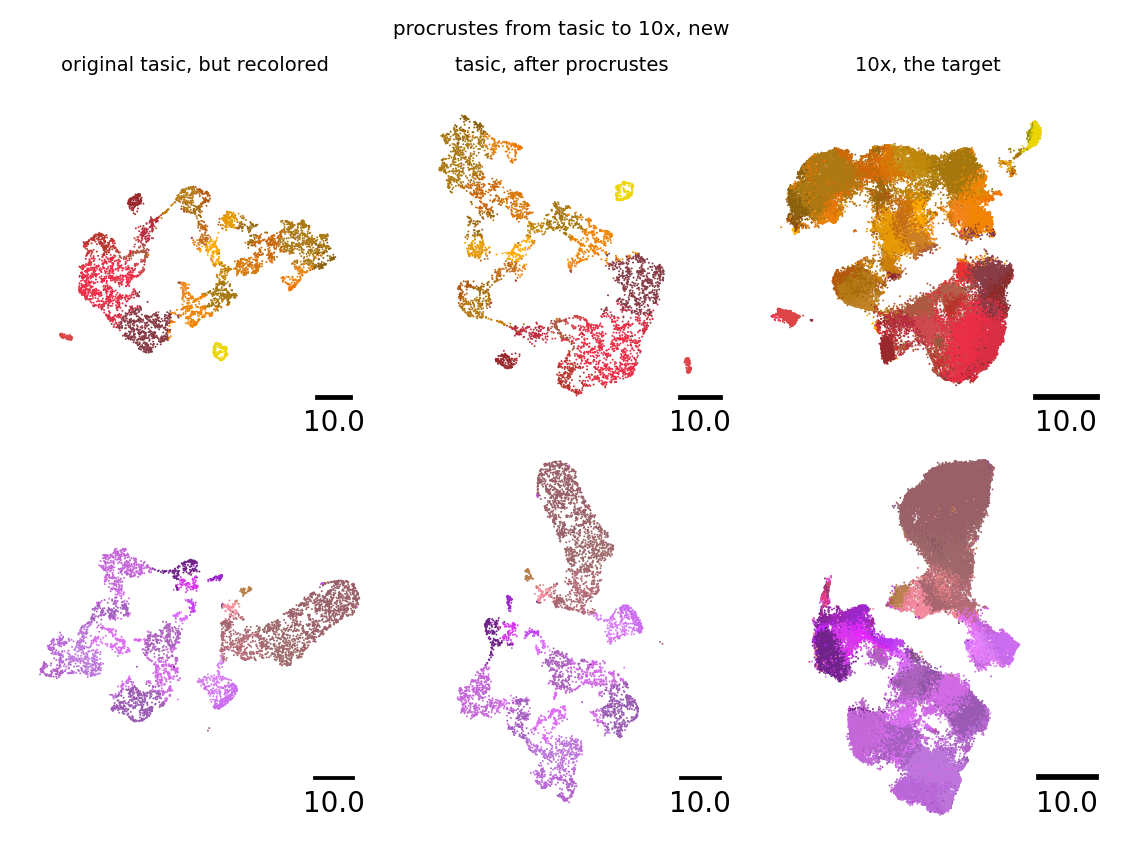

In [709]:
fig, ax = plt.subplots(2,3)
plot_scatter(ax[0,0], embd_tasic[mask_orange_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_orange_tasic_fig], s=2.0, alpha=1)
# ax[0,0].axis("on")
plot_scatter(ax[0,1], embd_tasic_after[mask_orange_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_orange_tasic_fig], s=2.0, alpha=1)
# ax[0,1].axis("on")
plot_scatter(ax[0,2], embd_10x_male[mask_orange_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_orange_10x_fig], s=2.0, alpha=1)
# ax[0,2].axis("on")

plot_scatter(ax[1,0], embd_tasic[mask_purple_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_purple_tasic_fig], s=2.0, alpha=1)
# ax[1,0].axis("on")
plot_scatter(ax[1,1], embd_tasic_after[mask_purple_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_purple_tasic_fig], s=2.0, alpha=1)
# ax[1,1].axis("on")
plot_scatter(ax[1,2], embd_10x_male[mask_purple_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_purple_10x_fig], s=2.0, alpha=1)
# ax[1,2].axis("on")


fig.suptitle("procrustes from tasic to 10x, new")
ax[0,0].set_xlim(-50, 40)
ax[0,0].set_ylim(20, 80)
ax[0,0].set_title("original tasic, but recolored")
ax[0,1].set_xlim(-75, 0)
ax[0,1].set_ylim(-60, 10)
ax[0,1].set_title("tasic, after procrustes")
ax[0,2].set_xlim(-65, -15)
ax[0,2].set_ylim(25, 70)
ax[0,2].set_title("10x, the target")

ax[1,0].set_xlim(-85, 5)
ax[1,0].set_ylim(-25, 25)
ax[1,1].set_xlim(-40, 20)
ax[1,1].set_ylim(-85, 5)
ax[1,2].set_xlim(-90, -40)
ax[1,2].set_ylim(-30, 30)
fig.savefig(os.path.join(fig_path, f"procrustes_tasic_new.png"), dpi=300)

# ------------------ both together! ----------------------------------

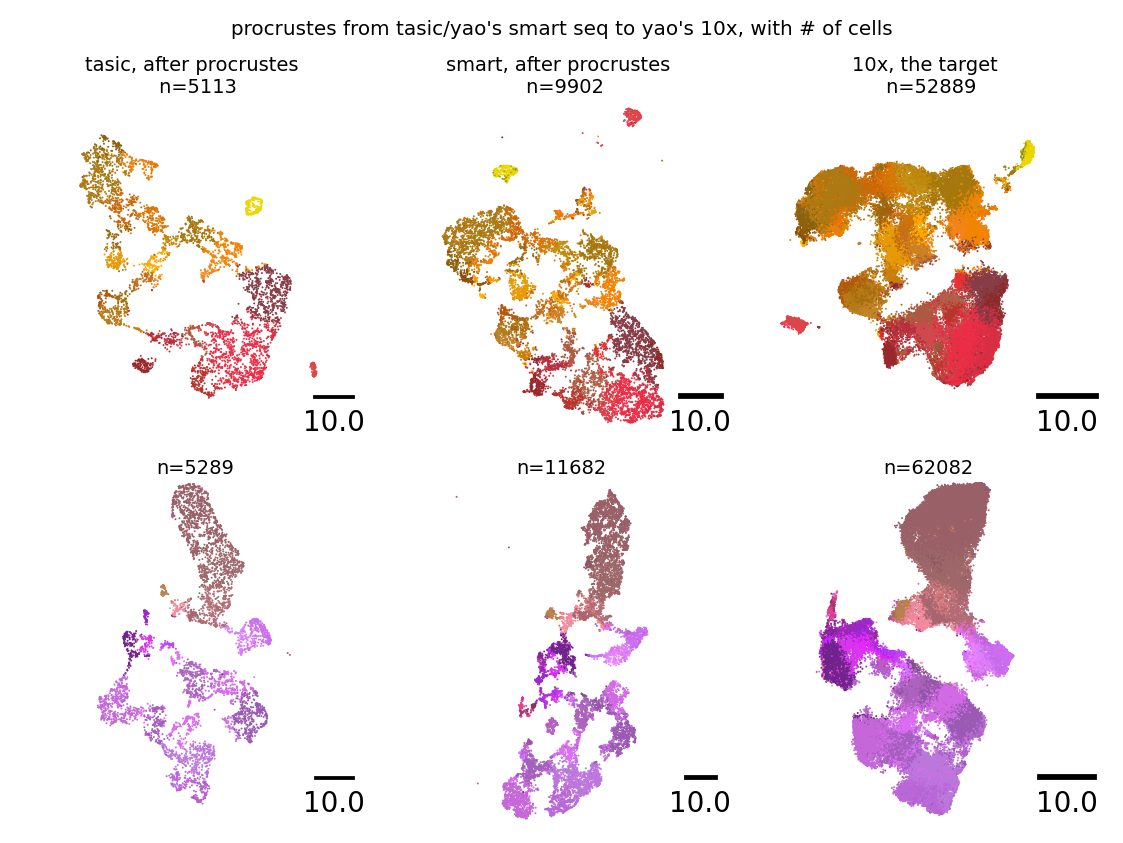

In [ ]:
fig, ax = plt.subplots(2,3)
fig.suptitle("procrustes from tasic/yao's smart seq to yao's 10x, with # of cells")
plot_scatter(ax[0,0], embd_tasic_after[mask_orange_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_orange_tasic_fig], s=2.0, alpha=1)
plot_scatter(ax[0,1], embd_smart_after[mask_orange_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_orange_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[0,2], embd_10x_male[mask_orange_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_orange_10x_fig], s=2.0, alpha=1)

plot_scatter(ax[1,0], embd_tasic_after[mask_purple_tasic_fig], y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_purple_tasic_fig], s=2.0, alpha=1)
plot_scatter(ax[1,1], embd_smart_after[mask_purple_smart_fig], y=d_smart['clusterColors'][d_smart['clusters']][mask_purple_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[1,2], embd_10x_male[mask_purple_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_purple_10x_fig], s=2.0, alpha=1)

ax[0,0].set_xlim(-75, 0)
ax[0,0].set_ylim(-60, 10)
ax[0,0].set_title(f"tasic, after procrustes \n n={sum(mask_orange_tasic_fig)}")
ax[0,1].set_xlim(-20, 40)
ax[0,1].set_ylim(5, 85)
ax[0,1].set_title(f"smart, after procrustes \n n={sum(mask_orange_smart_fig)}")
ax[0,2].set_xlim(-65, -15)
ax[0,2].set_ylim(25, 70)
ax[0,2].set_title(f"10x, the target \n n={sum(mask_orange_10x_fig)}")


ax[1,0].set_xlim(-40, 20)
ax[1,0].set_ylim(-85, 5)
ax[1,0].set_title(f"n={sum(mask_purple_tasic_fig)}")
ax[1,1].set_xlim(20, 80)
ax[1,1].set_ylim(-70, 40)
ax[1,1].set_title(f"n={sum(mask_purple_smart_fig)}")
ax[1,2].set_xlim(-90, -40)
ax[1,2].set_ylim(-30, 30)
ax[1,2].set_title(f"n={sum(mask_purple_10x_fig)}")
fig.savefig(os.path.join(fig_path, f"procrustes_both_new.png"), dpi=300)

# ------------------ 4 datasets together!----------------------------------

In [ ]:
idx_orange_10x_female_fig = [i for i, cluster in enumerate(d_10x_female["clusterNames"]) 
              if "_Sst" in cluster or "_Pvalb" in cluster]
mask_orange_10x_female_fig = [idx in idx_orange_10x_female_fig for idx in d_10x_female['clusters']]
idx_purple_10x_female_fig = [i for i, cluster in enumerate(d_10x_female["clusterNames"]) 
              if "_Lamp5" in cluster and "Lhx6" not in cluster or "_Vip" in cluster or "_Sncg" in cluster or "_Pax6" in cluster or "_Ntng1" in cluster]
mask_purple_10x_female_fig = [idx in idx_purple_10x_female_fig for idx in d_10x_female['clusters']]


In [ ]:
_,_,_,_, d_10x_female = load_dataset(root_path, "yao_10x_female", k=15, seed=0)

In [ ]:
embd_10x_female_n_mask_orange = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_10x_female_orange.npy"))
embd_10x_female_n_mask_purple = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_10x_female_purple.npy"))

embd_tasic_n_mask_orange = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_tasic_orange.npy"))
embd_tasic_n_mask_purple = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_tasic_purple.npy"))

embd_smart_n_mask_orange = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_smart_orange.npy"))
embd_smart_n_mask_purple = np.load(os.path.join(root_path, "embd_n_mask","embd_after_procrustes", "embd_smart_purple.npy"))


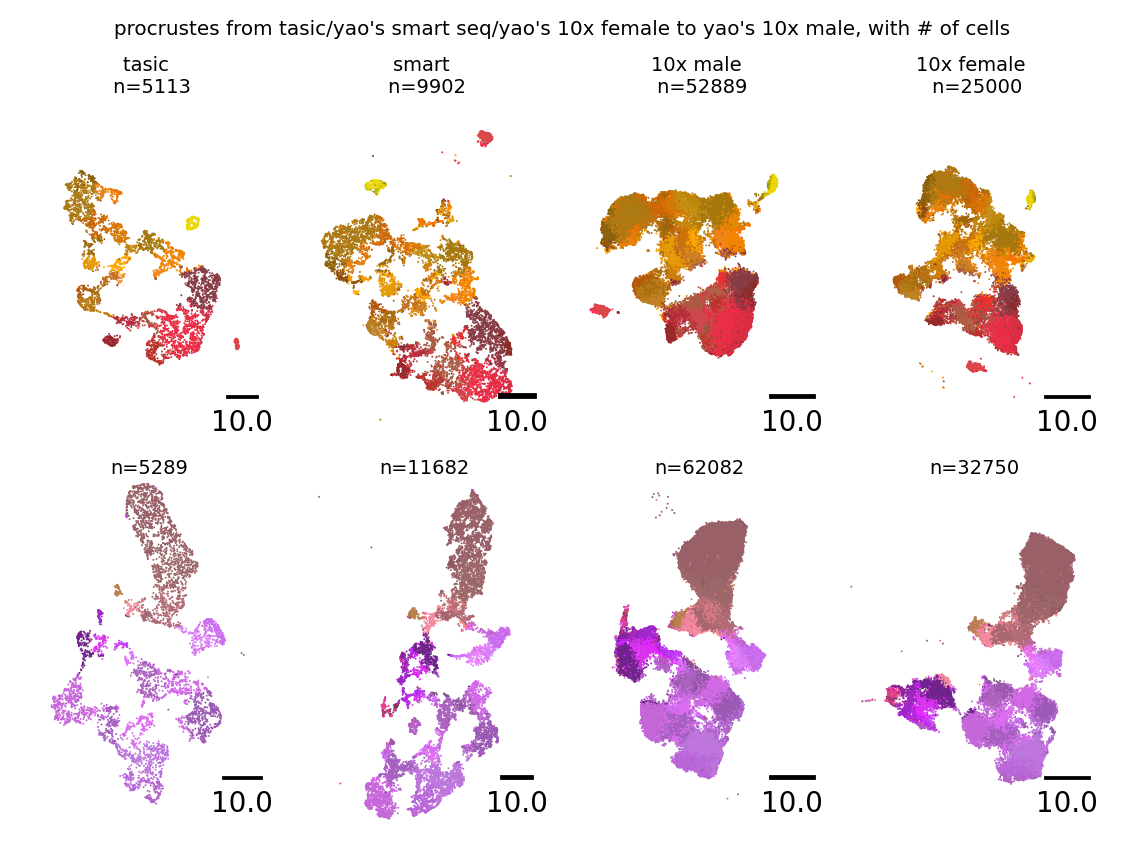

In [ ]:
fig, ax = plt.subplots(2,4)
fig.suptitle("procrustes from tasic/yao's smart seq/yao's 10x female to yao's 10x male, with # of cells")
plot_scatter(ax[0,0], embd_tasic_n_mask_orange, y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_orange_tasic_fig], s=2.0, alpha=1)
plot_scatter(ax[0,1], embd_smart_n_mask_orange, y=d_smart['clusterColors'][d_smart['clusters']][mask_orange_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[0,2], embd_10x_male[mask_orange_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_orange_10x_fig], s=2.0, alpha=1)
plot_scatter(ax[0,3], embd_10x_female_n_mask_orange, y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_orange_10x_female_fig], s=2.0, alpha=1)

plot_scatter(ax[1,0], embd_tasic_n_mask_purple, y=d_tasic['clusterColors_new'][d_tasic['clusters_new']][mask_purple_tasic_fig], s=2.0, alpha=1)
plot_scatter(ax[1,1], embd_smart_n_mask_purple, y=d_smart['clusterColors'][d_smart['clusters']][mask_purple_smart_fig], s=2.0, alpha=1)
plot_scatter(ax[1,2], embd_10x_male[mask_purple_10x_fig], y=d_10x_male['clusterColors'][d_10x_male['clusters']][mask_purple_10x_fig], s=2.0, alpha=1)
plot_scatter(ax[1,3], embd_10x_female_n_mask_purple, y=d_10x_female['clusterColors'][d_10x_female['clusters']][mask_purple_10x_female_fig], s=2.0, alpha=1)

ax[0,0].set_xlim(-75, 0)
ax[0,0].set_ylim(-60, 10)
ax[0,0].set_title(f"tasic \n n={sum(mask_orange_tasic_fig)}")
ax[0,1].set_xlim(-20, 40)
ax[0,1].set_ylim(5, 85)
ax[0,1].set_title(f"smart \n n={sum(mask_orange_smart_fig)}")
ax[0,2].set_xlim(-65, -15)
ax[0,2].set_ylim(25, 70)
ax[0,2].set_title(f"10x male \n n={sum(mask_orange_10x_fig)}")
ax[0,3].set_xlim(-90, -40)
ax[0,3].set_ylim(-10, 50)
ax[0,3].set_title(f"10x female \n n={embd_10x_female_n_mask_orange.shape[0]}")

ax[1,0].set_xlim(-40, 20)
ax[1,0].set_ylim(-85, 5)
ax[1,0].set_title(f"n={sum(mask_purple_tasic_fig)}")
ax[1,1].set_xlim(20, 80)
ax[1,1].set_ylim(-70, 40)
ax[1,1].set_title(f"n={sum(mask_purple_smart_fig)}")
ax[1,2].set_xlim(-90, -40)
ax[1,2].set_ylim(-30, 30)
ax[1,2].set_title(f"n={sum(mask_purple_10x_fig)}")
ax[1,3].set_xlim(-40, 10)
ax[1,3].set_ylim(-90, -20)
ax[1,3].set_title(f"n={embd_10x_female_n_mask_purple.shape[0]}")
fig.savefig(os.path.join(fig_path, f"procrustes_4.png"), dpi=300)